Accuracy: 100.00%

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



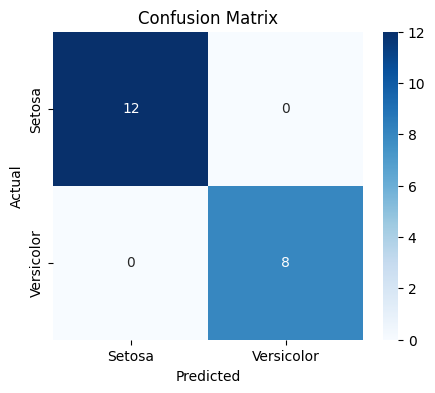

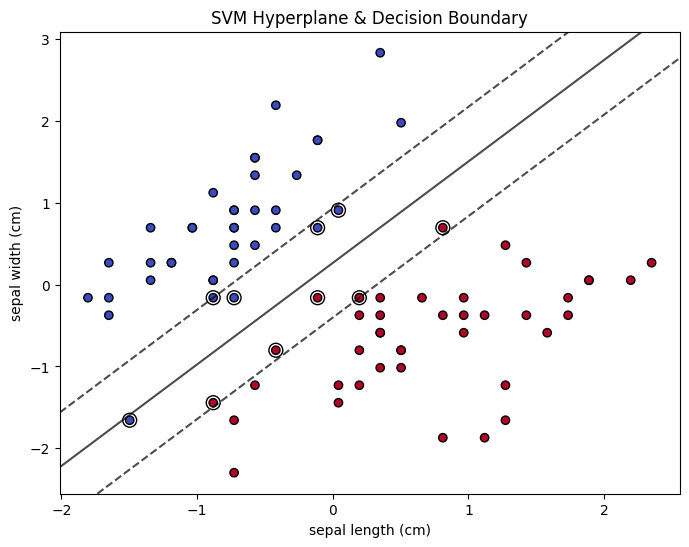

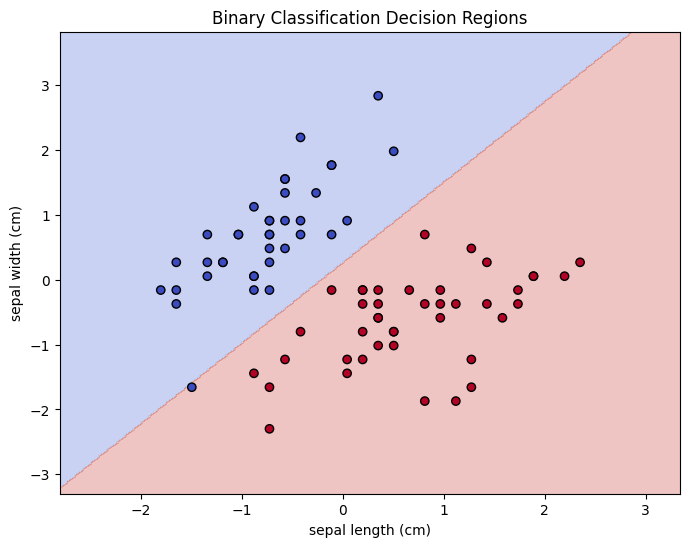

In [1]:
# ============================================
#   SVM Model — Iris Dataset (Binary Class)
#   With Hyperplane Visualization
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# --------------------------------------------
# 1. Load Dataset
# --------------------------------------------
iris = datasets.load_iris()

# Use only 2 classes for binary classification
X = iris.data[iris.target != 2, :2]   # first 2 features
y = iris.target[iris.target != 2]

# Actual feature names
feature_names = iris.feature_names[:2]

# --------------------------------------------
# 2. Train Test Split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------
# 3. Feature Scaling
# --------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------
# 4. Train SVM Model
# --------------------------------------------
model = SVC(kernel='linear', C=1)
model.fit(X_train, y_train)

# --------------------------------------------
# 5. Predictions (Updated with Names)
# --------------------------------------------
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

target_names = iris.target_names[:2]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# --------------------------------------------
# 6. Confusion Matrix
# --------------------------------------------
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["Setosa","Versicolor"],
    yticklabels=["Setosa","Versicolor"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------------------------
# 7. Visualization of Hyperplane & Regions
# --------------------------------------------

def plot_decision_boundary(model, X, y):

    plt.figure(figsize=(8,6))

    # Plot data points
    plt.scatter(
        X[:,0], X[:,1],
        c=y,
        cmap=plt.cm.coolwarm,
        edgecolors='k'
    )

    ax = plt.gca()

    # create grid
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)

    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy)
    Z = Z.reshape(XX.shape)

    # Plot decision boundary
    ax.contour(
        XX, YY, Z,
        colors='k',
        levels=[-1, 0, 1],
        alpha=0.7,
        linestyles=['--','-','--']
    )

    # Plot support vectors
    ax.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=100,
        linewidth=1,
        facecolors='none',
        edgecolors='black'
    )

    plt.title("SVM Hyperplane & Decision Boundary")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.show()

# Plot boundary
plot_decision_boundary(model, X_train, y_train)

# --------------------------------------------
# 8. Decision Region Visualization
# --------------------------------------------

def plot_regions(X, y, model):

    h = 0.02

    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))

    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

    plt.scatter(
        X[:,0], X[:,1],
        c=y,
        cmap=plt.cm.coolwarm,
        edgecolors='k'
    )

    plt.title("Binary Classification Decision Regions")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])

    plt.show()

plot_regions(X_train, y_train, model)